<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/heatpumps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Propane heat-pump performance and operating limits with NeqSim

This tutorial develops an idealized industrial propane heat pump from thermodynamic states to
process equipment, energy balances, operating sensitivities, and preliminary utility sizing. It
is intended for process engineers and advanced students familiar with steady-flow energy balances
and basic Python.

## Learning objectives

After completing the notebook, you can:

- calculate pure-propane saturation pressures with the SRK equation of state;
- assemble compressor, condenser, expansion-valve, and evaporator equipment in NeqSim;
- audit phase condition, enthalpy, mass flow, and complete-cycle energy closure;
- calculate heating COP and compare it with the Carnot upper bound;
- quantify source-temperature, sink-temperature, and compressor-efficiency effects; and
- scale a validated one-kilogram-per-second cycle to an industrial heating duty.

**Prerequisites:** Python fundamentals, thermodynamics, and a clean Google Colab runtime. All
inputs are synthetic and all displayed engineering quantities carry explicit SI-compatible units.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

print("NeqSim is available.")

NeqSim is available.


## 1. Runtime and model choice

Propane is a non-polar refrigerant, so the Soave–Redlich–Kwong (SRK) cubic equation of state is a
useful screening model. NeqSim represents the refrigerant as a thermodynamic system; `Stream`
objects add flow, while equipment objects perform the compression, heat-transfer, and pressure–
enthalpy calculations. The actual public PyPI package and Python/Java runtime versions are recorded.

In [2]:
import importlib.metadata
import platform
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from neqsim import jneqsim
from neqsim.thermo import TPflash, fluid


neqsim_version = importlib.metadata.version("neqsim")
java_version = subprocess.check_output(
    ["java", "-version"],
    stderr=subprocess.STDOUT,
    text=True,
).splitlines()[0]

runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [neqsim_version, platform.python_version(), java_version],
    }
)
display(runtime_table)

,Runtime,Version
0,NeqSim,3.16.0
1,Python,3.12.13
2,Java,"openjdk version ""17.0.19"" 2026-04-21"


## 2. Heat-pump cycle and sign convention

The four steady-flow steps are compression, condensation, isenthalpic expansion, and evaporation.
With specific enthalpy $h$ in kJ/kg, the positive energy quantities per unit refrigerant mass are

$$
w_c=h_2-h_1
$$

$$
q_{source}=h_1-h_4
$$

$$
q_{sink}=h_2-h_3
$$

Subscripts 1–4 denote compressor suction, compressor discharge, condenser outlet, and expansion-
valve outlet. The valve should satisfy $h_3=h_4$.

## 3. Base-case assumptions

The source-side refrigerant evaporates at $-5\,^{\circ}\mathrm{C}$ and the sink-side refrigerant
condenses at $45\,^{\circ}\mathrm{C}$. Five kelvin of suction superheat protects the compressor
from liquid carry-over, three kelvin of liquid subcooling stabilizes the valve inlet, and compressor
isentropic efficiency is 75%. The basis is 1 kg/s propane.

Pressure drops, exchanger heat leakage, compressor mechanical and motor losses, oil circulation,
and auxiliary electricity are omitted. Propane is flammable; the example is thermodynamic screening,
not package selection, hazardous-area design, or safety approval.

In [3]:
base_inputs = {
    "Evaporating temperature [°C]": -5.0,
    "Condensing temperature [°C]": 45.0,
    "Suction superheat [K]": 5.0,
    "Liquid subcooling [K]": 3.0,
    "Isentropic efficiency [-]": 0.75,
    "Refrigerant flow [kg/s]": 1.0,
}

display(
    pd.DataFrame(
        {
            "Input": list(base_inputs),
            "Value": list(base_inputs.values()),
        }
    )
)

,Input,Value
0,Evaporating temperature [°C],-5.00
1,Condensing temperature [°C],45.00
2,Suction superheat [K],5.00
3,Liquid subcooling [K],3.00
4,Isentropic efficiency [-],0.75
5,Refrigerant flow [kg/s],1.00


## 4. Saturation pressures define the lift

A pure-component bubble-point pressure flash locates vapour–liquid equilibrium at each specified
temperature. The resulting low and high pressures are calculated boundaries, not magic constants.
For pure propane the bubble and dew pressures are identical away from the critical point.

In [4]:
def propane_saturation_pressure_bara(temperature_c):
    saturation_fluid = fluid("srk")
    saturation_fluid.addComponent("propane", 1.0)
    saturation_fluid.setMixingRule("classic")
    saturation_fluid.setTemperature(temperature_c, "C")
    saturation_fluid.setPressure(5.0, "bara")
    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(
        saturation_fluid
    )
    operations.bubblePointPressureFlash(False)
    return float(saturation_fluid.getPressure("bara"))


low_pressure_bara = propane_saturation_pressure_bara(
    base_inputs["Evaporating temperature [°C]"]
)
high_pressure_bara = propane_saturation_pressure_bara(
    base_inputs["Condensing temperature [°C]"]
)

pressure_table = pd.DataFrame(
    {
        "Boundary": ["Heat source / evaporator", "Heat sink / condenser"],
        "Saturation temperature [°C]": [
            base_inputs["Evaporating temperature [°C]"],
            base_inputs["Condensing temperature [°C]"],
        ],
        "Saturation pressure [bara]": [low_pressure_bara, high_pressure_bara],
    }
)
display(pressure_table)

,Boundary,Saturation temperature [°C],Saturation pressure [bara]
0,Heat source / evaporator,-5.0,4.072618
1,Heat sink / condenser,45.0,15.558303


## 5. Reusable NeqSim heat-pump function

The process chain is `stream → compressor → cooler → valve → heater`. In heat-pump language the
`Cooler` is the condenser that delivers useful heat and the `Heater` is the evaporator that absorbs
heat from the source. Each scenario creates a fresh fluid and fresh equipment, avoiding hidden
mutable state between sensitivity cases.

In [5]:
Stream = jneqsim.process.equipment.stream.Stream
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve


def build_propane_heat_pump(
    evaporating_temperature_c,
    condensing_temperature_c,
    superheat_k=5.0,
    subcooling_k=3.0,
    isentropic_efficiency=0.75,
    refrigerant_flow_kg_s=1.0,
):
    low_pressure = propane_saturation_pressure_bara(evaporating_temperature_c)
    high_pressure = propane_saturation_pressure_bara(condensing_temperature_c)

    suction_fluid = fluid("srk")
    suction_fluid.addComponent("propane", 1.0)
    suction_fluid.setMixingRule("classic")
    suction_fluid.setTemperature(evaporating_temperature_c + superheat_k, "C")
    suction_fluid.setPressure(low_pressure, "bara")
    suction_fluid.setTotalFlowRate(refrigerant_flow_kg_s, "kg/sec")
    TPflash(suction_fluid)
    suction_fluid.initProperties()

    suction = Stream("heat-pump compressor suction", suction_fluid)
    suction.setFlowRate(refrigerant_flow_kg_s, "kg/sec")
    suction.run()

    compressor = Compressor("heat-pump compressor", suction)
    compressor.setOutletPressure(high_pressure, "bara")
    compressor.setIsentropicEfficiency(isentropic_efficiency)
    compressor.run()

    condenser = Cooler("heat-pump condenser", compressor.getOutletStream())
    condenser.setOutTemperature(condensing_temperature_c - subcooling_k, "C")
    condenser.run()

    valve = ThrottlingValve("heat-pump expansion valve", condenser.getOutletStream())
    valve.setOutletPressure(low_pressure, "bara")
    valve.run()

    evaporator = Heater("heat-pump evaporator", valve.getOutletStream())
    evaporator.setOutTemperature(evaporating_temperature_c + superheat_k, "C")
    evaporator.run()

    source_heat_kw = float(evaporator.getDuty()) / 1.0e3
    compressor_kw = float(compressor.getPower("kW"))
    useful_heat_kw = -float(condenser.getDuty()) / 1.0e3

    return {
        "suction": suction,
        "compressor": compressor,
        "condenser": condenser,
        "valve": valve,
        "evaporator": evaporator,
        "low_pressure_bara": low_pressure,
        "high_pressure_bara": high_pressure,
        "source_heat_kw": source_heat_kw,
        "compressor_kw": compressor_kw,
        "useful_heat_kw": useful_heat_kw,
        "heating_cop": useful_heat_kw / compressor_kw,
    }

## 6. Execute the base cycle

Every equipment item is run in process order. The evaporator outlet should reproduce the specified
compressor-suction state, closing this open representation of a circulating heat-pump loop.

In [6]:
base_case = build_propane_heat_pump(
    evaporating_temperature_c=base_inputs["Evaporating temperature [°C]"],
    condensing_temperature_c=base_inputs["Condensing temperature [°C]"],
    superheat_k=base_inputs["Suction superheat [K]"],
    subcooling_k=base_inputs["Liquid subcooling [K]"],
    isentropic_efficiency=base_inputs["Isentropic efficiency [-]"],
    refrigerant_flow_kg_s=base_inputs["Refrigerant flow [kg/s]"],
)

print(f"Low-side pressure: {base_case['low_pressure_bara']:.6f} bara")
print(f"High-side pressure: {base_case['high_pressure_bara']:.6f} bara")
print(f"Useful heating duty: {base_case['useful_heat_kw']:.6f} kW")
print(f"Compressor power: {base_case['compressor_kw']:.6f} kW")

Low-side pressure: 4.072618 bara
High-side pressure: 15.558303 bara
Useful heating duty: 350.883859 kW
Compressor power: 86.601718 kW


## 7. State and phase audit

The intended sequence is vapour at compressor suction and discharge, liquid at the condenser
outlet, a two-phase mixture after throttling, and vapour after evaporation. Vapour fraction is
assembled from the phase fractions returned by NeqSim rather than inferred from temperature alone.

In [7]:
def vapour_fraction(system):
    vapour_beta = 0.0

    for phase_index in range(system.getNumberOfPhases()):
        phase = system.getPhase(phase_index)

        if str(phase.getPhaseTypeName()).lower() == "gas":
            vapour_beta += float(phase.getBeta())

    return vapour_beta


state_streams = [
    ("1 Compressor suction", base_case["suction"]),
    ("2 Compressor discharge", base_case["compressor"].getOutletStream()),
    ("3 Condenser outlet", base_case["condenser"].getOutletStream()),
    ("4 Expansion-valve outlet", base_case["valve"].getOutletStream()),
    ("1 Evaporator outlet", base_case["evaporator"].getOutletStream()),
]
state_rows = []

for state_name, state_stream in state_streams:
    state_fluid = state_stream.getFluid()
    state_fluid.initProperties()
    state_rows.append(
        {
            "State": state_name,
            "Temperature [°C]": float(state_stream.getTemperature("C")),
            "Pressure [bara]": float(state_stream.getPressure("bara")),
            "Enthalpy [kJ/kg]": float(state_fluid.getEnthalpy("kJ/kg")),
            "Entropy [kJ/(kg K)]": float(state_fluid.getEntropy("kJ/kgK")),
            "Vapour fraction [-]": vapour_fraction(state_fluid),
            "Phases [-]": int(state_fluid.getNumberOfPhases()),
        }
    )

state_table = pd.DataFrame(state_rows)
display(state_table)

,State,Temperature [°C],Pressure [bara],Enthalpy [kJ/kg],Entropy [kJ/(kg K)],Vapour fraction [-],Phases [-]
0,1 Compressor suction,0.000000,4.072618,-12.367628,-0.291988,1.000000,1
1,2 Compressor discharge,65.530519,15.558303,74.234090,-0.227078,1.000000,1
2,3 Condenser outlet,42.000000,15.558303,-276.649769,-1.325876,0.000000,1
3,4 Expansion-valve outlet,-5.000000,4.072618,-276.649769,-1.277283,0.340549,2
4,1 Evaporator outlet,0.000000,4.072618,-12.367628,-0.291988,1.000000,1


## 8. Heating COP and complete energy closure

The heating coefficient of performance is useful sink heat divided by compressor work:

$$
\mathrm{COP}_H=\frac{q_{sink}}{w_c}
$$

The cycle must satisfy $q_{sink}=q_{source}+w_c$. Independent NeqSim equipment duties are used to
test this balance, while the valve inlet and outlet enthalpies test isenthalpic throttling.

In [8]:
energy_residual_kw = (
    base_case["useful_heat_kw"]
    - base_case["source_heat_kw"]
    - base_case["compressor_kw"]
)
valve_inlet_enthalpy = float(
    base_case["condenser"].getOutletStream().getFluid().getEnthalpy("J/kg")
)
valve_outlet_enthalpy = float(
    base_case["valve"].getOutletStream().getFluid().getEnthalpy("J/kg")
)
valve_enthalpy_residual = valve_outlet_enthalpy - valve_inlet_enthalpy

performance_table = pd.DataFrame(
    {
        "Metric": [
            "Source heat absorbed",
            "Compressor power",
            "Useful sink heat",
            "Heating COP",
            "Cycle energy residual",
            "Valve enthalpy residual",
        ],
        "Value": [
            base_case["source_heat_kw"],
            base_case["compressor_kw"],
            base_case["useful_heat_kw"],
            base_case["heating_cop"],
            energy_residual_kw,
            valve_enthalpy_residual,
        ],
        "Unit": ["kW", "kW", "kW", "-", "kW", "J/kg"],
    }
)
display(performance_table)

,Metric,Value,Unit
0,Source heat absorbed,2.642821e+02,kW
1,Compressor power,8.660172e+01,kW
2,Useful sink heat,3.508839e+02,kW
3,Heating COP,4.051696e+00,-
4,Cycle energy residual,2.842171e-14,kW
5,Valve enthalpy residual,5.820766e-11,J/kg


## 9. Carnot heating-COP upper bound

For reservoirs at absolute temperatures $T_{source}$ and $T_{sink}$, a reversible heat pump has

$$
\mathrm{COP}_{H,Carnot}=\frac{T_{sink}}{T_{sink}-T_{source}}
$$

The real-cycle COP must remain below this upper bound. Saturation temperatures are used here; real
exchangers require approach-temperature margins, so the practical reservoir lift is larger.

In [9]:
source_temperature_k = base_inputs["Evaporating temperature [°C]"] + 273.15
sink_temperature_k = base_inputs["Condensing temperature [°C]"] + 273.15
carnot_heating_cop = sink_temperature_k / (
    sink_temperature_k - source_temperature_k
)
fraction_of_carnot = base_case["heating_cop"] / carnot_heating_cop

carnot_table = pd.DataFrame(
    {
        "Quantity": [
            "NeqSim heating COP",
            "Carnot heating COP",
            "Fraction of Carnot COP",
        ],
        "Value": [
            base_case["heating_cop"],
            carnot_heating_cop,
            fraction_of_carnot,
        ],
        "Unit": ["-", "-", "-"],
    }
)
display(carnot_table)

,Quantity,Value,Unit
0,NeqSim heating COP,4.051696,-
1,Carnot heating COP,6.363000,-
2,Fraction of Carnot COP,0.636759,-


## 10. Pressure–enthalpy cycle map

The log-pressure diagram exposes the compression, condensation, throttling, and evaporation steps.
It is the calculated four-state equipment path, not a full refrigerant property chart.

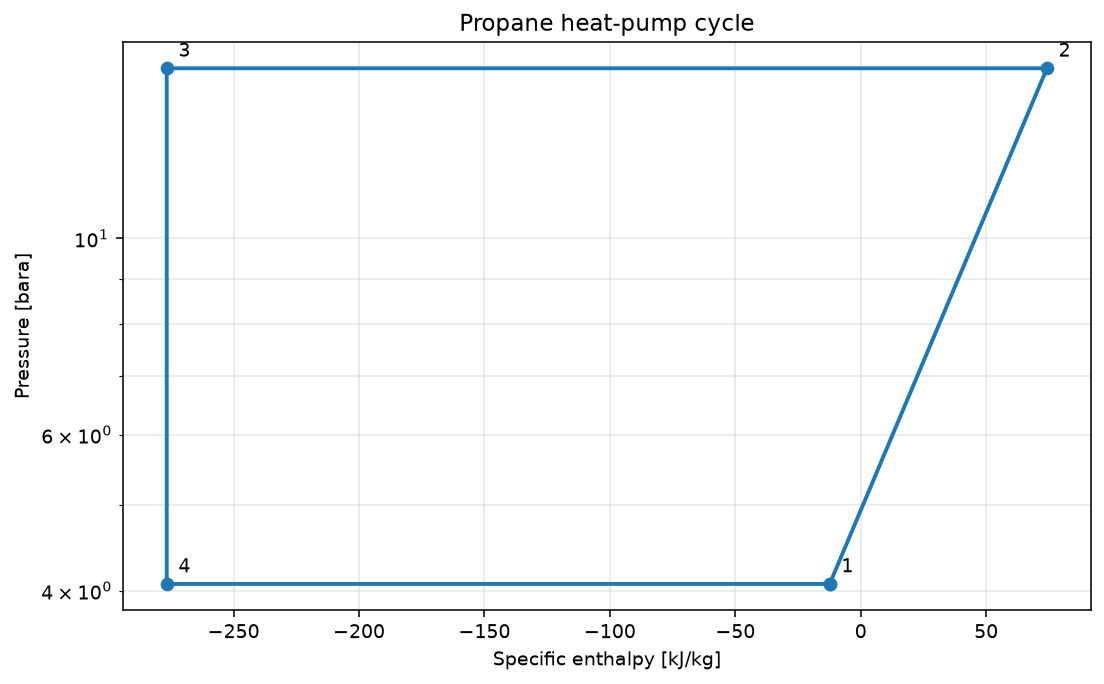

In [10]:
cycle_states = state_table.iloc[:4]
cycle_enthalpy = cycle_states["Enthalpy [kJ/kg]"].tolist()
cycle_pressure = cycle_states["Pressure [bara]"].tolist()
cycle_enthalpy.append(cycle_enthalpy[0])
cycle_pressure.append(cycle_pressure[0])

fig, axis = plt.subplots(figsize=(8, 5))
axis.plot(cycle_enthalpy, cycle_pressure, marker="o", linewidth=2)

for row_index, row in cycle_states.iterrows():
    axis.annotate(
        str(row_index + 1),
        (row["Enthalpy [kJ/kg]"], row["Pressure [bara]"]),
        xytext=(6, 6),
        textcoords="offset points",
    )

axis.set_yscale("log")
axis.set_xlabel("Specific enthalpy [kJ/kg]")
axis.set_ylabel("Pressure [bara]")
axis.set_title("Propane heat-pump cycle")
axis.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

## 11. Sink-temperature sensitivity

Raising delivery temperature increases condensing pressure and compressor lift. Heating COP should
therefore fall as the required sink temperature rises, all else held constant.

In [11]:
sink_rows = []

for condensing_temperature_c in [35.0, 40.0, 45.0, 50.0, 55.0]:
    scenario = build_propane_heat_pump(
        evaporating_temperature_c=-5.0,
        condensing_temperature_c=condensing_temperature_c,
    )
    sink_rows.append(
        {
            "Condensing temperature [°C]": condensing_temperature_c,
            "High pressure [bara]": scenario["high_pressure_bara"],
            "Compressor power [kW]": scenario["compressor_kw"],
            "Useful heat [kW]": scenario["useful_heat_kw"],
            "Heating COP [-]": scenario["heating_cop"],
        }
    )

sink_table = pd.DataFrame(sink_rows)
display(sink_table)

,Condensing temperature [°C],High pressure [bara],Compressor power [kW],Useful heat [kW],Heating COP [-]
0,35.0,12.333774,71.479397,366.391401,5.125832
1,40.0,13.878366,79.173388,358.977870,4.534072
2,45.0,15.558303,86.601718,350.883859,4.051696
3,50.0,17.380224,93.768027,342.071735,3.648064
4,55.0,19.350819,100.676283,332.495530,3.302620


## 12. Source-temperature sensitivity

A warmer source raises suction pressure and reduces lift. Source temperatures are represented by
refrigerant evaporation temperatures; a real source fluid must remain warmer by the exchanger
approach temperature. Heating COP should increase with source temperature.

In [12]:
source_rows = []

for evaporating_temperature_c in [-15.0, -10.0, -5.0, 0.0, 5.0]:
    scenario = build_propane_heat_pump(
        evaporating_temperature_c=evaporating_temperature_c,
        condensing_temperature_c=45.0,
    )
    source_rows.append(
        {
            "Evaporating temperature [°C]": evaporating_temperature_c,
            "Low pressure [bara]": scenario["low_pressure_bara"],
            "Compressor power [kW]": scenario["compressor_kw"],
            "Useful heat [kW]": scenario["useful_heat_kw"],
            "Heating COP [-]": scenario["heating_cop"],
        }
    )

source_table = pd.DataFrame(source_rows)
display(source_table)

,Evaporating temperature [°C],Low pressure [bara],Compressor power [kW],Useful heat [kW],Heating COP [-]
0,-15.0,2.915598,108.439606,360.478558,3.324233
1,-10.0,3.457745,97.292514,355.487077,3.653797
2,-5.0,4.072618,86.601718,350.883859,4.051696
3,0.0,4.766067,76.337879,346.626809,4.540692
4,5.0,5.544064,66.475464,342.676687,5.154935


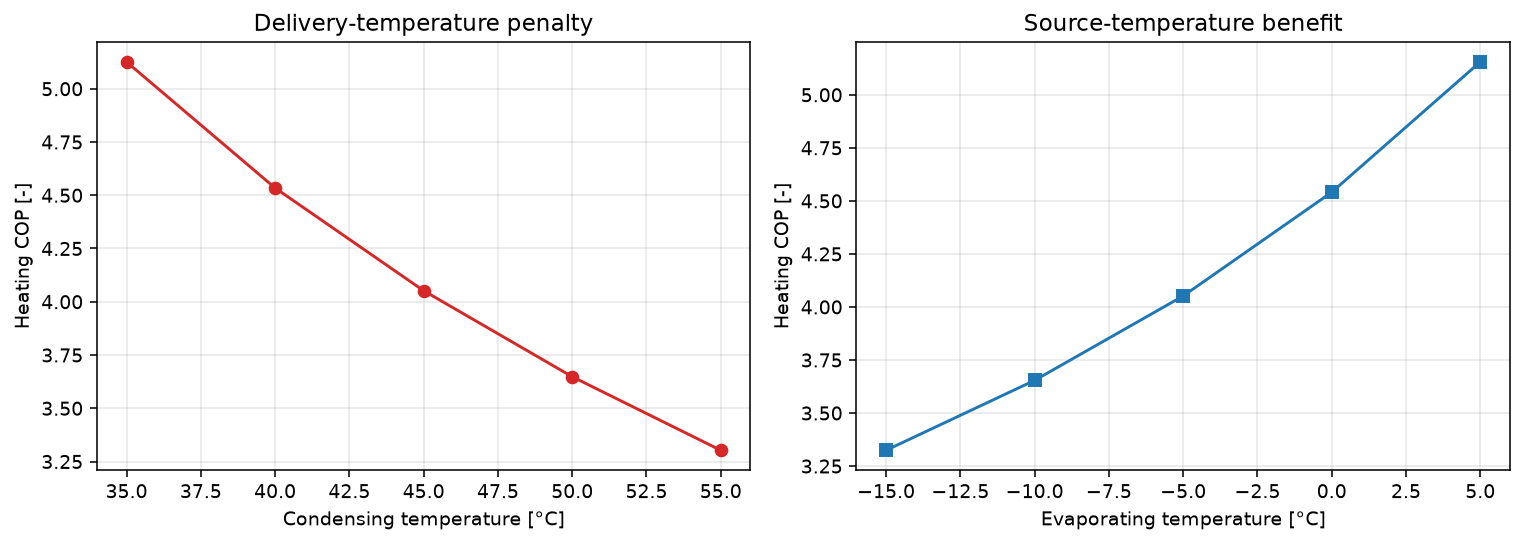

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(
    sink_table["Condensing temperature [°C]"],
    sink_table["Heating COP [-]"],
    marker="o",
    color="tab:red",
)
axes[0].set_xlabel("Condensing temperature [°C]")
axes[0].set_ylabel("Heating COP [-]")
axes[0].set_title("Delivery-temperature penalty")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    source_table["Evaporating temperature [°C]"],
    source_table["Heating COP [-]"],
    marker="s",
    color="tab:blue",
)
axes[1].set_xlabel("Evaporating temperature [°C]")
axes[1].set_ylabel("Heating COP [-]")
axes[1].set_title("Source-temperature benefit")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 13. Compressor-efficiency sensitivity

Isentropic efficiency converts the reversible enthalpy rise into the actual rise. Better efficiency
must reduce compressor power and increase heating COP. This sweep does not represent a compressor
map, speed limit, surge boundary, motor efficiency, or off-design volumetric-capacity limit.

In [14]:
efficiency_rows = []

for isentropic_efficiency in [0.60, 0.70, 0.75, 0.80, 0.90]:
    scenario = build_propane_heat_pump(
        evaporating_temperature_c=-5.0,
        condensing_temperature_c=45.0,
        isentropic_efficiency=isentropic_efficiency,
    )
    efficiency_rows.append(
        {
            "Isentropic efficiency [-]": isentropic_efficiency,
            "Compressor power [kW]": scenario["compressor_kw"],
            "Useful heat [kW]": scenario["useful_heat_kw"],
            "Heating COP [-]": scenario["heating_cop"],
        }
    )

efficiency_table = pd.DataFrame(efficiency_rows)
display(efficiency_table)

,Isentropic efficiency [-],Compressor power [kW],Useful heat [kW],Heating COP [-]
0,0.60,108.252148,372.534288,3.441357
1,0.70,92.787555,357.069696,3.848250
2,0.75,86.601718,350.883859,4.051696
3,0.80,81.189111,345.471251,4.255143
4,0.90,72.168098,336.450239,4.662036


## 14. Scale to a 1 MW heating service

For target heating duty $\dot Q_{target}$, refrigerant circulation follows

$$
\dot m_{ref}=\frac{\dot Q_{target}}{q_{sink}}
$$

For a secondary-water temperature rise $\Delta T_w$, a preliminary water-flow estimate is

$$
\dot m_w=\frac{\dot Q_{target}}{c_{p,w}\Delta T_w}
$$

The water calculation uses $c_{p,w}=4.18$ kJ/(kg K); detailed design requires temperature-dependent
properties, exchanger approaches, pressure drop, fouling, controls, and hydraulic sizing.

In [15]:
target_heating_kw = 1_000.0
required_refrigerant_flow_kg_s = (
    target_heating_kw / base_case["useful_heat_kw"]
)
scaled_case = build_propane_heat_pump(
    evaporating_temperature_c=-5.0,
    condensing_temperature_c=45.0,
    refrigerant_flow_kg_s=required_refrigerant_flow_kg_s,
)

water_heat_capacity_kj_kg_k = 4.18
water_temperature_rise_k = 10.0
required_water_flow_kg_s = target_heating_kw / (
    water_heat_capacity_kj_kg_k * water_temperature_rise_k
)

scale_table = pd.DataFrame(
    {
        "Quantity": [
            "Target useful heat",
            "Required propane circulation",
            "Calculated useful heat",
            "Compressor power",
            "Source heat extracted",
            "Secondary-water flow",
        ],
        "Value": [
            target_heating_kw,
            required_refrigerant_flow_kg_s,
            scaled_case["useful_heat_kw"],
            scaled_case["compressor_kw"],
            scaled_case["source_heat_kw"],
            required_water_flow_kg_s,
        ],
        "Unit": ["kW", "kg/s", "kW", "kW", "kW", "kg/s"],
    }
)
display(scale_table)

,Quantity,Value,Unit
0,Target useful heat,1000.000000,kW
1,Required propane circulation,2.849946,kg/s
2,Calculated useful heat,1000.000000,kW
3,Compressor power,246.810208,kW
4,Source heat extracted,753.189792,kW
5,Secondary-water flow,23.923445,kg/s


## 15. Seasonal operating-point illustration

A single design COP is not an annual performance factor. The synthetic bins below connect outdoor
temperature to an assumed evaporation temperature five kelvin lower and to a simple heating-load
profile. Electrical energy is calculated as heating energy divided by bin COP. Defrost, standby,
pumps, fans, and part-load cycling are excluded, so this is a transparent illustration rather than
a climate benchmark.

In [16]:
seasonal_inputs = pd.DataFrame(
    {
        "Outdoor temperature [°C]": [-10.0, -5.0, 0.0, 5.0, 10.0],
        "Hours [h]": [250.0, 500.0, 900.0, 1000.0, 600.0],
        "Heating load [kW]": [1000.0, 850.0, 650.0, 450.0, 250.0],
    }
)
seasonal_rows = []

for _, row in seasonal_inputs.iterrows():
    evaporation_temperature_c = row["Outdoor temperature [°C]"] - 5.0
    scenario = build_propane_heat_pump(
        evaporating_temperature_c=evaporation_temperature_c,
        condensing_temperature_c=45.0,
    )
    heating_energy_mwh = row["Heating load [kW]"] * row["Hours [h]"] / 1.0e3
    electric_energy_mwh = heating_energy_mwh / scenario["heating_cop"]
    seasonal_rows.append(
        {
            "Outdoor temperature [°C]": row["Outdoor temperature [°C]"],
            "Hours [h]": row["Hours [h]"],
            "Heating load [kW]": row["Heating load [kW]"],
            "Heating COP [-]": scenario["heating_cop"],
            "Heating energy [MWh]": heating_energy_mwh,
            "Electric energy [MWh]": electric_energy_mwh,
        }
    )

seasonal_table = pd.DataFrame(seasonal_rows)
seasonal_performance_factor = seasonal_table["Heating energy [MWh]"].sum() / (
    seasonal_table["Electric energy [MWh]"].sum()
)
display(seasonal_table)
print(f"Illustrative seasonal performance factor: {seasonal_performance_factor:.6f}")

Illustrative seasonal performance factor: 4.007681


,Outdoor temperature [°C],Hours [h],Heating load [kW],Heating COP [-],Heating energy [MWh],Electric energy [MWh]
0,-10.0,250.0,1000.0,3.324233,250.0,75.205310
1,-5.0,500.0,850.0,3.653797,425.0,116.317360
2,0.0,900.0,650.0,4.051696,585.0,144.383972
3,5.0,1000.0,450.0,4.540692,450.0,99.103834
4,10.0,600.0,250.0,5.154935,150.0,29.098331


## 16. Focused engineering verification

Assertions cover phase intent, saturation ordering, energy and valve closure, thermodynamic bounds,
finite results, monotonic sensitivities, scale-up, seasonal accounting, and closure of the circulating
state. Tolerances represent numerical precision rather than rounded display values.

In [17]:
checks = {
    "NeqSim 3.x installed": neqsim_version.startswith("3."),
    "low pressure positive": base_case["low_pressure_bara"] > 1.0,
    "high pressure exceeds low": (
        base_case["high_pressure_bara"] > base_case["low_pressure_bara"]
    ),
    "suction is vapour": state_table.iloc[0]["Vapour fraction [-]"] > 0.999,
    "discharge is vapour": state_table.iloc[1]["Vapour fraction [-]"] > 0.999,
    "condenser outlet is liquid": state_table.iloc[2]["Vapour fraction [-]"] < 1.0e-9,
    "valve outlet is two phase": state_table.iloc[3]["Phases [-]"] == 2,
    "evaporator outlet is vapour": state_table.iloc[4]["Vapour fraction [-]"] > 0.999,
    "source heat positive": base_case["source_heat_kw"] > 0.0,
    "compressor power positive": base_case["compressor_kw"] > 0.0,
    "useful heat positive": base_case["useful_heat_kw"] > 0.0,
    "cycle energy closes": abs(energy_residual_kw) < 1.0e-6,
    "valve is isenthalpic": abs(valve_enthalpy_residual) < 1.0e-3,
    "heating COP plausible": 1.0 < base_case["heating_cop"] < 10.0,
    "heating COP below Carnot": base_case["heating_cop"] < carnot_heating_cop,
    "fraction of Carnot bounded": 0.2 < fraction_of_carnot < 0.9,
    "state table finite": np.isfinite(
        state_table.select_dtypes(include="number").to_numpy()
    ).all(),
    "sink cases finite": np.isfinite(
        sink_table.select_dtypes(include="number").to_numpy()
    ).all(),
    "sink pressure rises": np.all(np.diff(sink_table["High pressure [bara]"]) > 0.0),
    "sink COP falls": np.all(np.diff(sink_table["Heating COP [-]"]) < 0.0),
    "source cases finite": np.isfinite(
        source_table.select_dtypes(include="number").to_numpy()
    ).all(),
    "source pressure rises": np.all(
        np.diff(source_table["Low pressure [bara]"]) > 0.0
    ),
    "source COP rises": np.all(np.diff(source_table["Heating COP [-]"]) > 0.0),
    "efficiency cases finite": np.isfinite(
        efficiency_table.select_dtypes(include="number").to_numpy()
    ).all(),
    "efficiency lowers power": np.all(
        np.diff(efficiency_table["Compressor power [kW]"]) < 0.0
    ),
    "efficiency raises COP": np.all(
        np.diff(efficiency_table["Heating COP [-]"]) > 0.0
    ),
    "scaled heat meets target": (
        abs(scaled_case["useful_heat_kw"] - target_heating_kw) < 1.0e-6
    ),
    "refrigerant flow positive": required_refrigerant_flow_kg_s > 0.0,
    "water flow positive": required_water_flow_kg_s > 0.0,
    "seasonal table finite": np.isfinite(
        seasonal_table.select_dtypes(include="number").to_numpy()
    ).all(),
    "seasonal factor plausible": 1.0 < seasonal_performance_factor < 10.0,
    "evaporator closes temperature": abs(
        state_table.iloc[4]["Temperature [°C]"]
        - state_table.iloc[0]["Temperature [°C]"]
    ) < 1.0e-8,
    "evaporator closes enthalpy": abs(
        state_table.iloc[4]["Enthalpy [kJ/kg]"]
        - state_table.iloc[0]["Enthalpy [kJ/kg]"]
    ) < 1.0e-8,
}

failed_checks = [name for name, passed in checks.items() if not passed]

if failed_checks:
    raise AssertionError(f"Failed engineering checks: {failed_checks}")

print(f"All {len(checks)} engineering checks passed.")

All 33 engineering checks passed.


## 17. Applicability, limitations, and troubleshooting

This workflow supports concept screening, heat-integration studies, utility estimates, teaching,
and the thermodynamic core of a larger NeqSim process. It does not replace certified heat-pump
package design or project safety engineering.

Limitations:

- Validate SRK refrigerant properties against authoritative data for detailed design.
- Add source/sink approach temperatures, exchanger pressure drops, fouling, and area constraints.
- Add compressor maps, motor and mechanical efficiency, speed limits, turndown, and auxiliaries.
- Propane service requires containment, ventilation, hazardous-area classification, detection,
  relief, shutdown, and emergency-response design under applicable project codes.
- The seasonal illustration excludes defrost, cycling, standby, fans, pumps, and availability.

Troubleshooting:

- If suction is two phase, increase superheat or verify low-side pressure and temperature units.
- If the valve outlet is single phase, verify calculated saturation pressures and liquid subcooling.
- If duty signs appear reversed, distinguish NeqSim equipment signs from the positive cycle magnitudes.
- Rebuild each sensitivity case from a fresh fluid to avoid carrying mutable state between cases.

In [18]:
summary_table = pd.DataFrame(
    {
        "Result": [
            "Low-side pressure",
            "High-side pressure",
            "Useful heat per 1 kg/s",
            "Compressor power per 1 kg/s",
            "Heating COP",
            "Fraction of Carnot COP",
            "Propane flow for 1 MW",
            "Secondary-water flow for 10 K rise",
            "Illustrative seasonal performance factor",
            "Cycle energy residual",
        ],
        "Value": [
            base_case["low_pressure_bara"],
            base_case["high_pressure_bara"],
            base_case["useful_heat_kw"],
            base_case["compressor_kw"],
            base_case["heating_cop"],
            fraction_of_carnot,
            required_refrigerant_flow_kg_s,
            required_water_flow_kg_s,
            seasonal_performance_factor,
            energy_residual_kw,
        ],
        "Unit": ["bara", "bara", "kW", "kW", "-", "-", "kg/s", "kg/s", "-", "kW"],
    }
)
display(summary_table)

,Result,Value,Unit
0,Low-side pressure,4.072618e+00,bara
1,High-side pressure,1.555830e+01,bara
2,Useful heat per 1 kg/s,3.508839e+02,kW
3,Compressor power per 1 kg/s,8.660172e+01,kW
4,Heating COP,4.051696e+00,-
5,Fraction of Carnot COP,6.367588e-01,-
6,Propane flow for 1 MW,2.849946e+00,kg/s
7,Secondary-water flow for 10 K rise,2.392344e+01,kg/s
8,Illustrative seasonal performance factor,4.007681e+00,-
9,Cycle energy residual,2.842171e-14,kW


## Summary, exercises, and references

The NeqSim model combines rigorous phase-equilibrium flashes with composable process equipment.
The base case demonstrates correct phase intent, isenthalpic throttling, complete energy closure,
a heating COP below the Carnot bound, and physically correct source, sink, and efficiency trends.

Suggested exercises:

1. Add realistic source and sink approach temperatures and exchanger pressure drops.
2. Compare SRK and Peng–Robinson while keeping every boundary condition identical.
3. Include motor efficiency, source/sink pumps, and fan power in a system COP.
4. Replace constant compressor efficiency with a speed-dependent performance map.
5. Add a natural-gas process stream as the heat source and a closed water loop as the sink.

References:

- [NeqSim process simulation documentation](https://equinor.github.io/neqsim/process/README.html)
- [NeqSim process recipes](https://equinor.github.io/neqsim/cookbook/process-recipes.html)
- [NeqSim heat-exchanger documentation](https://equinor.github.io/neqsim/process/equipment/heat_exchangers)
- [NeqSim thermodynamic operations](https://equinor.github.io/neqsim/thermodynamicoperations/README.html)
- [Public NeqSim package on PyPI](https://pypi.org/project/neqsim/)